In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
data=pd.read_csv('/content/drive/MyDrive/AI/test_Y3wMUE5_7gLdaTN.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [91]:
data=data.drop(['Married','Loan_ID'],axis=1)
data


,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,Male,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,Male,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,Male,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,Male,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...
362,Male,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,Male,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,Male,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,Male,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [92]:
data["Dependents"].value_counts()

,count
Dependents,
0,200
2,59
1,58
3+,40


In [93]:

data['Self_Employed']=data['Self_Employed'].map({'Yes':1,'No':0})
data['Education']=data['Education'].map({'Graduate':1,'Not Graduate':0})
data['Property_Area']=data['Property_Area'].map({'Urban':2,'Rural':0,'Semiurban':1})
data['Gender']=data['Gender'].map({'Male':1,'Female':0})
data['Dependents']=data['Dependents'].map({'3+':3,"1":1,"2":2,"0":0})

data

,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1.0,0.0,1,0.0,5720,0,110.0,360.0,1.0,2
1,1.0,1.0,1,0.0,3076,1500,126.0,360.0,1.0,2
2,1.0,2.0,1,0.0,5000,1800,208.0,360.0,1.0,2
3,1.0,2.0,1,0.0,2340,2546,100.0,360.0,NaN,2
4,1.0,0.0,0,0.0,3276,0,78.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...
362,1.0,3.0,0,1.0,4009,1777,113.0,360.0,1.0,2
363,1.0,0.0,1,0.0,4158,709,115.0,360.0,1.0,2
364,1.0,0.0,1,0.0,3250,1993,126.0,360.0,NaN,1
365,1.0,0.0,1,0.0,5000,2393,158.0,360.0,1.0,0


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             356 non-null    float64
 1   Dependents         357 non-null    float64
 2   Education          367 non-null    int64  
 3   Self_Employed      344 non-null    float64
 4   ApplicantIncome    367 non-null    int64  
 5   CoapplicantIncome  367 non-null    int64  
 6   LoanAmount         362 non-null    float64
 7   Loan_Amount_Term   361 non-null    float64
 8   Credit_History     338 non-null    float64
 9   Property_Area      367 non-null    int64  
dtypes: float64(6), int64(4)
memory usage: 28.8 KB


In [95]:
data.isnull()

,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
362,False,False,False,False,False,False,False,False,False,False
363,False,False,False,False,False,False,False,False,False,False
364,False,False,False,False,False,False,False,False,True,False
365,False,False,False,False,False,False,False,False,False,False


In [98]:
avg=data['Dependents'].mean()
data['Dependents']=data['Dependents'].fillna(avg)
avg=data['LoanAmount'].mean()
data['LoanAmount']=data['LoanAmount'].fillna(data['LoanAmount'].mean())
avg=data['Loan_Amount_Term'].mean()
data['Loan_Amount_Term']=data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean())
data["Loan_Amount_Term"]=data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean())
avg=data['Credit_History'].mean()
data['Credit_History']=data['Credit_History'].fillna(data['Credit_History'].mean())
avg=data['Gender'].mean()
data['Gender']=data['Gender'].fillna(data['Gender'].mean())
avg=data['Self_Employed'].mean()
data['Self_Employed']=data['Self_Employed'].fillna(data['Self_Employed'].mean())
data

,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1.0,0.0,1,0.0,5720,0,110.0,360.0,1.000000,2
1,1.0,1.0,1,0.0,3076,1500,126.0,360.0,1.000000,2
2,1.0,2.0,1,0.0,5000,1800,208.0,360.0,1.000000,2
3,1.0,2.0,1,0.0,2340,2546,100.0,360.0,0.825444,2
4,1.0,0.0,0,0.0,3276,0,78.0,360.0,1.000000,2
...,...,...,...,...,...,...,...,...,...,...
362,1.0,3.0,0,1.0,4009,1777,113.0,360.0,1.000000,2
363,1.0,0.0,1,0.0,4158,709,115.0,360.0,1.000000,2
364,1.0,0.0,1,0.0,3250,1993,126.0,360.0,0.825444,1
365,1.0,0.0,1,0.0,5000,2393,158.0,360.0,1.000000,0


In [99]:
data.isnull().sum()

,0
Gender,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


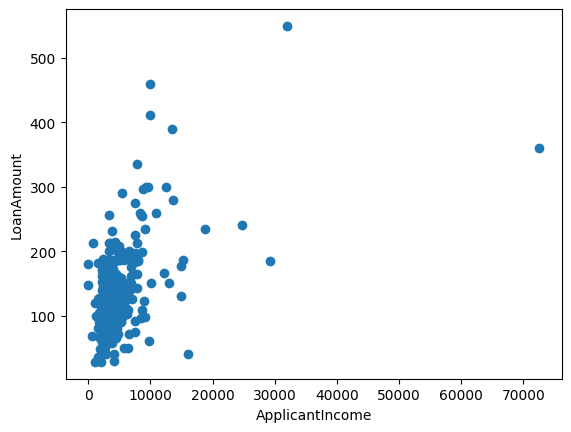

In [112]:
plt.scatter(data['ApplicantIncome'],data['LoanAmount'])
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.show()

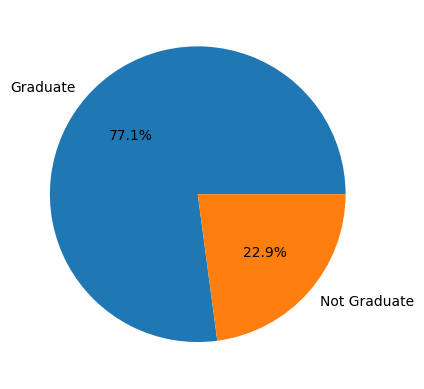

In [113]:
plt.pie(data['Education'].value_counts(),labels=data['Education'].value_counts().index,autopct='%1.1f%%')
plt.show()


In [100]:
x=data.drop('LoanAmount',axis=1)
y=data['LoanAmount']
y.head()


,LoanAmount
0,110.0
1,126.0
2,208.0
3,100.0
4,78.0


In [101]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("training record",len(x_train))
print("testing record",len(x_test ))

training record 293
testing record 74


In [102]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [103]:
model=LinearRegression()
model.fit(x_train,y_train)
print("slope",model.coef_[0])
print("intercept",model.intercept_)

slope 11.333302212034852
intercept 43.840597470846035


In [104]:
y_pred=model.predict(x_test)

In [107]:
y_pred=model.predict([[	1.0, 	1 ,	0.0 	,3076, 	1500 	,126.0 ,	360.0, 	1.000000 	,2]])
print(y_pred)

[42897.95962288]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


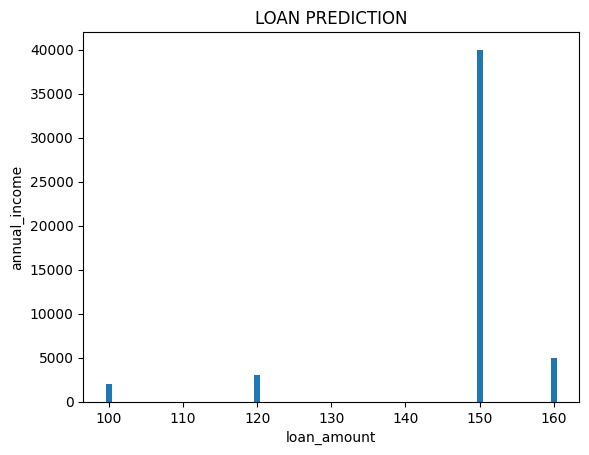

In [116]:
loan_amount=[100,120,150,160]
annual_income=[2000,3000,40000,5000]
plt.title('LOAN PREDICTION')
plt.xlabel('loan_amount')
plt.ylabel('annual_income')
plt.bar(loan_amount,annual_income)
plt.show()


In [115]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Married"] = le.fit_transform(data["Married"])
data["Married"]

,Married
0,1
1,1
2,1
3,1
4,0
...,...
362,1
363,1
364,0
365,1
